## 1. Foreword

Your problem statement will be the guiding force that will influence every question and decision making from this point onward. Before starting any of the exercises get that down.

It would be helpful to refresh the basics of statistical modelling and machine learnin before proceeding, here are the essential concepts that you should understand:

1. Exploratory Data Analysis (EDA):
    - Descriptive statistics (mean, median, variance, quantiles)
    - Understanding distributions and variability 

2. Data Pre-processing
    - Features & Target Transformation
    - Creating new features
    - Feature Selection

3. Regression Models: Linear Regression, Regularized Regression (Ridge, Lasso)
    - Interpreting coefficients, understanding R², MSE, MAE, RMSE

4. Classification Models: Logistic Regression, Decision Trees, Random Forests, SVMs, K-Nearest Neighbors
    - Interpreting probabilities, coefficients (log-odds), and feature importances

5. Evaluation Metrics:
    - For Regression: R², Mean Squared Error (MSE), Mean Absolute Error (MAE), Root Mean Squared Error (RMSE)
    - For Classification: Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Confusion Matrix

6. Model Selection & Validation:
    - Train-test splits, cross-validation techniques
    - Overfitting vs. underfitting
    - Hyperparameter tuning (grid search, random search)

7. Model Interpretability & Explainability:
    - Interpreting model coefficients and feature importance
    - Visualization of decision trees (using plot_tree)
    - Tools like SHAP and LIME for local/global explanations



#### The entire Data Science process would look something like:

1. Exploration: Start with EDA to understand your data. Ask questions about distributions, correlations, and anomalies.
2. Modeling:Build models using core algorithms, evaluate with relevant metrics, and examine model outputs (coefficients, feature importances).
3. Evaluation:Compare metrics against baselines, inspect errors, and assess whether the model meets the problem requirements.
4. Iteration:Use insights from the evaluation to refine feature engineering, adjust preprocessing steps, or try different models.
5. Repeat: Go through this process again—exploration, modeling, evaluation—until you reach the desired balance between performance, interpretability, and practical applicability, based on your problem statement


## 2. Assignment Tasks

1) Define a problem statement
2) Perform EDA (if you are choosing a new dataset)
3) Use EDA Insights for feature selection and feature engineering
4) Create your first 3 models using the framework I provide
5) Evaluate the model and then attempt to improve it
6) Interpret Model results and outputs (coefficients, trees) and continue to add to your insights.
7) Explore 2 new models of your choice. Some suggestions are KNN, SVM for classification & Ridge, Lasso for regression but there are so many more and part of the fun of data science is researching new ways to do things.


Please note that the tasks above are guidelines and this is more of an art than a science. Your specific problem might require some specialized techniques and steps. I implore you to question every characteristic of your dataset and models you encounter and ask "how can I use this to give me insights?" and "what technique can I apply to this to make it useful?".

Good luck and feel free to reach out with any questions.

## 3. Resources
1. Concise explanation for popular Machine learning models : https://www.youtube.com/watch?v=E0Hmnixke2g 
2. Fantastic sklearn algorithms cheat sheet : https://scikit-learn.org/stable/machine_learning_map.html
    - This sklearn tutorial by the sklearn team is amazing too : https://scikit-learn.org/1.4/tutorial/index.html
3. The Python Data Science handbook I linked last assignment has a great machine learning section that should help clear any basics.

These should help you get started but the best way to learn is start the process and when you encounter something you don't fully understand, look that up specifically and apply it. 

## 4. Predictive Modelling (Your Assignment Should be Below)

For reference, below is working code roughly following the guidelines and using the same dataset from the last couple sessions.

### Cleaning & Pre-Processing

In [19]:
import pandas as pd
import re

# Load dataset
df = pd.read_csv("laptops_dataset.csv")

# ---- Basic Cleaning ----
# Fill missing text
df["title"]  = df["title"].fillna("No Title")
df["review"] = df["review"].fillna("No Review")

# Convert numeric columns (remove commas if any)
for col in ["overall_rating", "no_ratings", "no_reviews", "rating"]:
    df[col] = (
        df[col].astype(str).str.replace(",", "", regex=False)
        .astype(float)
    )

# ---- Simple Feature Engineering ----
# Clean review text (basic lowercasing & removing punctuation)
def clean_text(text):
    return re.sub(r"[^a-z0-9\s]", "", str(text).lower())

df["review_clean"] = df["review"].apply(clean_text)

# Review length (as a quick numeric feature)
df["review_len"] = df["review_clean"].str.split().apply(len)

print(df.head())

                                        product_name  overall_rating  \
0  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...             4.7   
1  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...             4.7   
2  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...             4.7   
3  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...             4.7   
4  Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...             4.7   

   no_ratings  no_reviews  rating             title  \
0     15210.0       900.0     5.0  Perfect product!   
1     15210.0       900.0     5.0         Fabulous!   
2     15210.0       900.0     5.0         Fabulous!   
3     15210.0       900.0     4.0        Delightful   
4     15210.0       900.0     5.0           Awesome   

                                              review  \
0  Loved it, it's my first MacBook that I earned ...   
1  Battery lasted longer than my first relationsh...   
2  Such a great deal.. very happy with the perfor...   
3  Awesome b

#### Generating Sample Continuous Data to use regression

This is for demonstration only and doesn't allow for any meaningful regression analysis.


- Missing occupation, likely unemployed or self-emplployed? 
- missing workclass : likely the same set? 
- missing native country : could be bi-racial or just missing in the survey/input methodology

choosing to keep the missing values

### B. Classification Models


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load
df = pd.read_csv("laptops_dataset.csv")

# Minimal cleaning
for c in ["overall_rating", "no_ratings", "no_reviews", "rating"]:
    df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", "", regex=False), errors="coerce")

df = df.dropna(subset=["overall_rating", "no_ratings", "no_reviews", "rating"])

# Target: Positive(>=4) vs Negative(<4)
y = (df["overall_rating"] >= 4).astype(int)
X = df[["no_ratings", "no_reviews", "rating"]]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)

# Evaluate
pred = clf.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, pred), 4))

Accuracy: 0.8671


### C. Interpreting Results

#### Regression Coefficients

In [22]:
### Getting Regression Coefficients
# -------------------
# 6. Interpreting Results
# -------------------

print("\n=== Regression Coefficients ===")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature:15} : {coef:.4f}")

print(f"\nIntercept : {model.intercept_:.4f}")


=== Regression Coefficients ===
no_ratings      : 0.1056
no_reviews      : -0.0584
rating          : 0.0177

Intercept : 4.1992


The coefficients are interpreted as "the change in the target associated with a unit change in that variable, if all else remains the same". 
- A higher positive value means the feature has a strong positive association with the target.
- A negative value means the feature is inversely associated with the target.
- This helps in understanding which predictors have the most influence on your continuous target variable.

#### Log Odds for Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Train Logistic Regression
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)

# Print coefficients (log-odds)
print("=== Log Odds (Coefficients) ===")
for f, c in zip(X.columns, log_model.coef_[0]):
    print(f"{f}: {c:.4f}")

print("\nIntercept:", log_model.intercept_[0])

# Print odds ratios
print("\n=== Odds Ratios ===")
for f, c in zip(X.columns, log_model.coef_[0]):
    print(f"{f}: {np.exp(c):.4f}")

=== Log Odds (Coefficients) ===
no_ratings: 0.0004
no_reviews: -0.0033
rating: 0.2284

Intercept: 0.618606401228869

=== Odds Ratios ===
no_ratings: 1.0004
no_reviews: 0.9967
rating: 1.2566


The sign and magnitude of each log-odds coefficient indicate how a one-unit change in the feature affects the log odds of being in the positive class.

#### Visualizing a Decision Tree

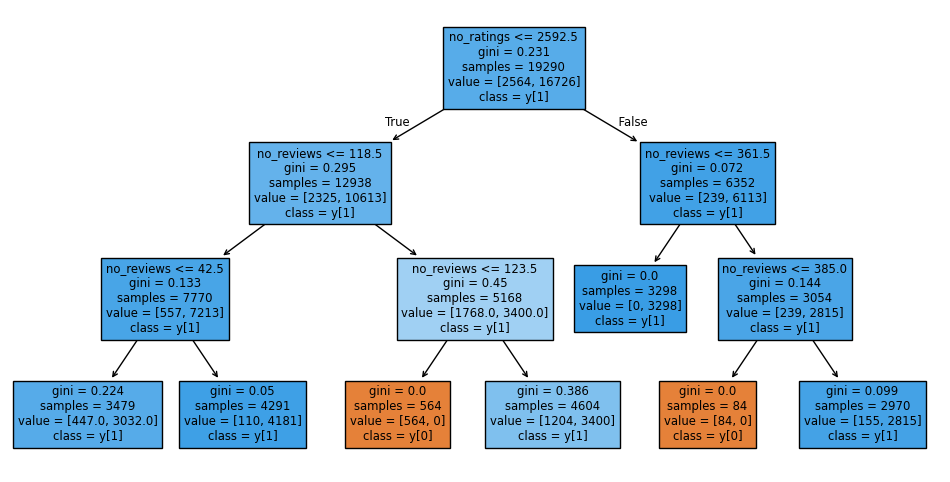

In [24]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Train a small decision tree (classification)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(12,6))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True)
plt.show()

#### Hyperparameter Tuning 

In [32]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Base model
dt_reg = DecisionTreeRegressor(random_state=42)

# Tiny grid
param_grid = {
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 5]
}

# Grid Search
grid = GridSearchCV(dt_reg, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV R² :", round(grid.best_score_, 4))

# Evaluate
best_reg = grid.best_estimator_
pred = best_reg.predict(X_test)

r2   = r2_score(y_test, pred)
mae  = mean_absolute_error(y_test, pred)
mse  = mean_squared_error(y_test, pred)
rmse = mse ** 0.5   # <-- manual RMSE

print(f"Test R²  : {r2:.4f}")
print(f"Test MAE : {mae:.4f}")
print(f"Test MSE : {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Python(38556) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Best params: {'max_depth': None, 'min_samples_leaf': 1}
Best CV R² : 0.9875
Test R²  : 0.9910
Test MAE : 0.0010
Test MSE : 0.0010
Test RMSE: 0.0322


Python(38557) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
